# Rae2822 2D Wing Slice Model

### Import Library

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

### Loading Data

In [2]:
folder_path = Path("./data/rae2822/angvar_sa")
case_dirs = sorted(
    [path for path in folder_path.iterdir() if path.is_dir()],
    key=lambda path: float(path.name),
) if folder_path.exists() else []

if not case_dirs:
    raise FileNotFoundError(
        f"No AoA case folders found in {folder_path.resolve()}. "
        "Download the Kaggle dataset and place rae2822/angvar_sa under data/."
    )

master_df = []

for case_dir in case_dirs:
    surface_csv = case_dir / "surface_flow.csv"
    if not surface_csv.exists():
        raise FileNotFoundError(f"Missing surface_flow.csv in {case_dir}")

    df = pd.read_csv(surface_csv)
    df['AoA'] = float(case_dir.name)
    master_df.append(df)

# Combine into one training set
full_data = pd.concat(master_df, ignore_index=True)
full_data = full_data[['Pressure_Coefficient', 'AoA', 'x', 'y']]
# full_data = full_data.dropna()
print(full_data[full_data.isna().any(axis=1)])


Empty DataFrame
Columns: [Pressure_Coefficient, AoA, x, y]
Index: []


In [3]:
print(f"Total rows: {len(full_data)}")
full_data[['Pressure_Coefficient', 'AoA', 'x', 'y']].head(300)

Total rows: 8256


,Pressure_Coefficient,AoA,x,y
0,0.262408,0.0,0.985397,0.000943
1,0.279663,0.0,0.969573,0.001489
2,0.293002,0.0,0.952680,0.001679
3,0.295781,0.0,0.934996,0.001511
4,0.292556,0.0,0.916822,0.000923
...,...,...,...,...
295,-0.423432,0.5,0.031993,0.022736
296,-0.428776,0.5,0.035372,0.023828
297,-0.431730,0.5,0.038915,0.024920
298,-0.443075,0.5,0.042590,0.026014


In [4]:
# sample_aoa = 0
# sample_case = full_data[full_data['AoA'] == sample_aoa]

# plt.figure(figsize=(10, 6))
# top_surface = sample_case[sample_case['y'] > 0].sort_values(by='x')
# bottom_surface = sample_case[sample_case['y'] <= 0].sort_values(by='x')

# plt.scatter(top_surface['x'], top_surface['Pressure_Coefficient'], color='purple', label='(Top Surface)')
# plt.scatter(bottom_surface['x'], bottom_surface['Pressure_Coefficient'],color='orange', label='(Bottom Surface)')
# plt.gca().invert_yaxis()
# plt.legend()
# plt.grid(True)
# plt.title(f"Sample Case: AoA = {sample_aoa}°")

# Model

In [16]:
# import model
import tensorflow as tf
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
import joblib

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [6]:
full_data['AoA_rad'] = np.deg2rad(full_data['AoA'])
full_data['sin_AoA'] = np.sin(full_data['AoA_rad'])
full_data['cos_AoA'] = np.cos(full_data['AoA_rad'])

# features = ['x', 'y', 'AoA']
features = ['x', 'y', 'sin_AoA', 'cos_AoA']
target = 'Pressure_Coefficient'

In [7]:
def build_model():
    reg = tf.keras.regularizers.l2(1e-6)
    # custom layer or MLP
    return tf.keras.Sequential([
        tf.keras.Input(shape=(4,)),
        tf.keras.layers.Dense(128, activation='swish', kernel_regularizer=reg),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(64, activation='swish', kernel_regularizer=reg),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(32, activation='swish', kernel_regularizer=reg),
        tf.keras.layers.Dense(1)
    ])

def build_early_stop():
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=25,          
        restore_best_weights=True
    )

logo = LeaveOneGroupOut()

aoa_values = full_data['AoA'].values
unique_aoas = np.unique(aoa_values)
X = full_data[features].values  # shape (n*192, 3)
y = full_data[target].values    # shape (n*192, 1)

val_scores = []
train_val_ratio = []
_round = 0

for train_idx, test_idx in logo.split(X, y, aoa_values):
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    X_train_s = scaler_X.fit_transform(X_train)
    X_test_s  = scaler_X.transform(X_test)

    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1))
    y_test_s  = scaler_y.transform(y_test.reshape(-1, 1))

    model = build_model()

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae'] # meaningful for regression
    )

    history = model.fit(
        X_train_s, y_train_s,
        epochs=200,
        validation_split=0.1,
        shuffle=True, # Ensure val split isn't just last 10% of rows (Random around the airfoil) not help
        callbacks=[build_early_stop()],
        verbose=0
    )

    final_train = history.history['loss'][-1]
    actual_epochs = len(history.history['loss'])
    final_val   = history.history['val_loss'][-1]
    gap_ratio   = final_val / final_train

    y_pred_s = model.predict(X_test_s)
    y_pred = scaler_y.inverse_transform(y_pred_s).flatten()

    mse = np.mean((y_pred - y_test)**2)
    mae = np.mean(np.abs(y_pred - y_test))

    # score = model.evaluate(y_test, y_pred, verbose=0) # mse, mae
    val_scores.append([mse, mae])
    train_val_ratio.append(gap_ratio)
    print(f"AoA {unique_aoas[_round]} → train: {final_train:.5f} | val: {final_val:.5f} | ratio: {gap_ratio:.2f}")
    print(f"\tStopped: {actual_epochs} epochs | MSE: {mse:.5f} | MAE: {mae:.5f}")
    _round += 1


val_scores = np.array(val_scores)  # shape (44, 2)
print(f"\nMean MSE: {np.mean(val_scores[:, 0]):.4f}")
print(f"\nMean MAE: {np.mean(val_scores[:, 1]):.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
AoA 0.0 → train: 0.01459 | val: 0.04128 | ratio: 2.83
	Stopped: 69 epochs | MSE: 0.00765 | MAE: 0.07535
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
AoA 0.5 → train: 0.01778 | val: 0.05664 | ratio: 3.19
	Stopped: 44 epochs | MSE: 0.00655 | MAE: 0.06461
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
AoA 1.0 → train: 0.01473 | val: 0.02598 | ratio: 1.76
	Stopped: 69 epochs | MSE: 0.00275 | MAE: 0.04222
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
AoA 1.5 → train: 0.01485 | val: 0.04415 | ratio: 2.97
	Stopped: 65 epochs | MSE: 0.00308 | MAE: 0.04940
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
AoA 2.0 → train: 0.01453 | val: 0.03377 | ratio: 2.32
	Stopped: 68 epochs | MSE: 0.00452 | MAE: 0.05004
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
AoA 2.5 → train: 0.00946 | val: 0.01722 | ratio: 1.82
	Stopped: 142 epochs | MSE: 0.00388 | MAE: 0.04741
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
AoA 3.0 → train: 0.01539 | val: 0.05238 | ratio: 3.40
	Stopped: 63 epochs | MSE: 0.00955 | MAE: 0.07059
6/6 ━

In [8]:
unique_aoas = np.unique(aoa_values)
for i, (aoa, score, ratio) in enumerate(zip(unique_aoas, val_scores, train_val_ratio)):
    print(f"AoA {aoa }° → MSE: {score[0]:.5f}, MAE: {score[1]:.5f}, Ratio: {ratio:.2f}")

AoA 0.0° → MSE: 0.00765, MAE: 0.07535, Ratio: 2.83
AoA 0.5° → MSE: 0.00655, MAE: 0.06461, Ratio: 3.19
AoA 1.0° → MSE: 0.00275, MAE: 0.04222, Ratio: 1.76
AoA 1.5° → MSE: 0.00308, MAE: 0.04940, Ratio: 2.97
AoA 2.0° → MSE: 0.00452, MAE: 0.05004, Ratio: 2.32
AoA 2.5° → MSE: 0.00388, MAE: 0.04741, Ratio: 1.82
AoA 3.0° → MSE: 0.00955, MAE: 0.07059, Ratio: 3.40
AoA 3.5° → MSE: 0.00375, MAE: 0.04108, Ratio: 3.87
AoA 4.0° → MSE: 0.00457, MAE: 0.04881, Ratio: 2.35
AoA 4.5° → MSE: 0.00369, MAE: 0.03777, Ratio: 2.24
AoA 5.0° → MSE: 0.00605, MAE: 0.05541, Ratio: 3.48
AoA 5.5° → MSE: 0.00492, MAE: 0.04962, Ratio: 1.67
AoA 6.0° → MSE: 0.00586, MAE: 0.04810, Ratio: 3.84
AoA 6.5° → MSE: 0.00648, MAE: 0.06100, Ratio: 1.44
AoA 7.0° → MSE: 0.00345, MAE: 0.03761, Ratio: 2.36
AoA 7.5° → MSE: 0.00767, MAE: 0.06113, Ratio: 1.93
AoA 8.0° → MSE: 0.00334, MAE: 0.03765, Ratio: 3.93
AoA 8.5° → MSE: 0.00422, MAE: 0.03766, Ratio: 1.76
AoA 9.0° → MSE: 0.00692, MAE: 0.05369, Ratio: 3.64
AoA 9.5° → MSE: 0.00801, MAE: 0

In [9]:
# train final model with full dataset
final_scaler_X = StandardScaler()
final_scaler_y = StandardScaler()

full_feature = full_data[features].values
full_target = full_data[target].values

full_X_s = final_scaler_X.fit_transform(full_feature)
full_y_s = final_scaler_y.fit_transform(full_target.reshape(-1, 1))

final_model = build_model()

final_model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
final_model.fit(
        full_X_s, full_y_s,
        epochs=200,
        validation_split=0.1,
        shuffle=True,
        callbacks=[build_early_stop()],
        verbose=0,
    )


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


c:\Users\KongP\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


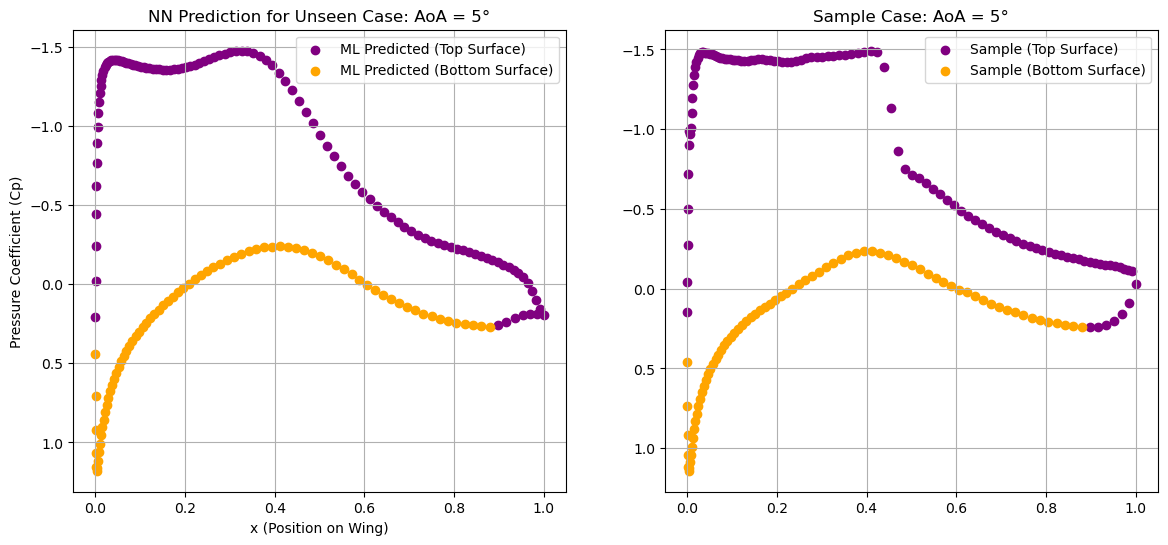

In [10]:
predict_aoa = 5

# predict_scaler_X = StandardScaler()
# predict_scaler_y = StandardScaler()

# geometry = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy().reset_index(drop=True)

X_new = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy().reset_index(drop=True)
X_new['sin_AoA'] = np.sin(np.deg2rad(predict_aoa))
X_new['cos_AoA'] = np.cos(np.deg2rad(predict_aoa))

# predict
X_new_s = final_scaler_X.transform(X_new[features])

Cp_predicted_s = final_model.predict(X_new_s)
Cp_predicted = final_scaler_y.inverse_transform(Cp_predicted_s)

# map back — just attach prediction to the same rows
result = X_new[['x', 'y']].copy()
result['Cp_predicted'] = Cp_predicted

# sample_aoa = 0
sample_case = full_data[full_data['AoA'] == predict_aoa]

fig, (pred, samp) = plt.subplots(1, 2, figsize=(14,6))

# plt.figure(figsize=(10, 6))
top_surface_samp = sample_case[sample_case['y'] > 0].sort_values(by='x')
bottom_surface_samp = sample_case[sample_case['y'] <= 0].sort_values(by='x')

samp.scatter(top_surface_samp['x'], top_surface_samp['Pressure_Coefficient'], color='purple', label='Sample (Top Surface)')
samp.scatter(bottom_surface_samp['x'], bottom_surface_samp['Pressure_Coefficient'],color='orange', label='Sample (Bottom Surface)')
samp.invert_yaxis()
samp.legend()
samp.grid(True)
samp.set_title(f"Sample Case: AoA = {predict_aoa}°")

top_surface_pred = result[result['y'] > 0].sort_values(by='x')
bottom_surface_pred = result[result['y'] <= 0].sort_values(by='x')

pred.scatter(top_surface_pred['x'], top_surface_pred['Cp_predicted'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
pred.scatter(bottom_surface_pred['x'], bottom_surface_pred['Cp_predicted'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

pred.invert_yaxis() # Invert y-axis for Aerodynamics
pred.set_title(f"NN Prediction for Unseen Case: AoA = {predict_aoa}°")
pred.set_xlabel("x (Position on Wing)")
pred.set_ylabel("Pressure Coefficient (Cp)")
pred.legend()
pred.grid(True)

In [ ]:
# MANUAL RUN ONLY!
# final_model.save("cfd_model.keras")
# joblib.dump(final_scaler_X, 'scaler_X.pkl')
# joblib.dump(final_scaler_y, 'scaler_y.pkl')

In [ ]:
# MANUAL RUN ONLY!
# final_model.export("cfd_nn_model")
# joblib.dump(final_scaler_X, 'scaler_X.pkl')
# joblib.dump(final_scaler_y, 'scaler_y.pkl')

['scaler_y.pkl']

In [13]:
# predict_aoa = 5

# # predict_scaler_X = StandardScaler()
# # predict_scaler_y = StandardScaler()

# # geometry = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy().reset_index(drop=True)

# X_new = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy().reset_index(drop=True)
# X_new['sin_AoA'] = np.sin(np.deg2rad(predict_aoa))
# X_new['cos_AoA'] = np.cos(np.deg2rad(predict_aoa))

# # predict
# X_new_s = final_scaler_X.transform(X_new[features])

# Cp_predicted_s = final_model.predict(X_new_s)
# Cp_predicted = final_scaler_y.inverse_transform(Cp_predicted_s)

# # map back — just attach prediction to the same rows
# result = X_new[['x', 'y']].copy()
# result['Cp_predicted'] = Cp_predicted

# # print(result)

# plt.figure(figsize=(10, 6))
# top_surface = result[result['y'] > 0].sort_values(by='x')
# bottom_surface = result[result['y'] <= 0].sort_values(by='x')

# plt.scatter(top_surface['x'], top_surface['Cp_predicted'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
# plt.scatter(bottom_surface['x'], bottom_surface['Cp_predicted'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

# plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
# plt.title(f"NN Prediction for Unseen Case: AoA = {predict_aoa}°")
# plt.xlabel("x (Position on Wing)")
# plt.ylabel("Pressure Coefficient (Cp)")
# plt.legend()
# plt.grid(True)
# plt.show()

In [14]:
# aoa_degrees = np.linspace(0, 360, 100)
# aoa_radians = np.deg2rad(aoa_degrees)

# # 2. Apply the Trigonometric Normalization
# sin_aoa = np.sin(aoa_radians)
# cos_aoa = np.cos(aoa_radians)

# # 3. Create a side-by-side visualization
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# # --- Plot 1: The Bounded Waves ---
# ax1.plot(aoa_degrees, sin_aoa, label='sin_AoA', color='blue', linewidth=2)
# ax1.plot(aoa_degrees, cos_aoa, label='cos_AoA', color='red', linewidth=2, linestyle='--')
# ax1.set_title("1. Bounding Features between [-1, 1]")
# ax1.set_xlabel("Original Angle of Attack (Degrees)")
# ax1.set_ylabel("Normalized Feature Value")
# ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
# ax1.legend()
# ax1.grid(True, alpha=0.4)

# # --- Plot 2: The Unit Circle Projection ---
# # We use color to map back to the original angle
# cmap = plt.cm.cool
# scatter = ax2.scatter(cos_aoa, sin_aoa, c=aoa_degrees, cmap='twilight_shifted', edgecolor='k')
# ax2.set_title("2. New Feature Space (Cyclical Continuity)")
# ax2.set_xlabel("cos_AoA")
# ax2.set_ylabel("sin_AoA")
# ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
# ax2.axvline(0, color='black', linewidth=0.8, linestyle=':')
# ax2.set_aspect('equal') # Forces the axes to be proportional (perfect circle)
# plt.colorbar(scatter, ax=ax2, label='Original AoA (Degrees)')

# plt.tight_layout()
# plt.show()